# Lab 09: Regression Analysis

**Regression** finds a model $\hat{y} = f(x; \mathbf{c})$ that best describes the relationship
between data by minimizing the sum of squared residuals:
$$\min_{\mathbf{c}} \; S_r = \sum_{i=1}^{n} [y_i - f(x_i; \mathbf{c})]^2$$

Unlike interpolation (exact fit), regression **smooths** noisy data and extracts trends.

## Learning Objectives

By the end of this session, you will be able to:
- Compute sample statistics and visualize data distributions
- Derive and implement **Simple Linear Regression** from scratch
- Evaluate model quality with $R^2$, adjusted $R^2$, $s_e$, and residual plots
- Fit **power-law** and **exponential** models via log-linearization
- Solve **General Linear Least Squares** using the normal equations $(\mathbf{X}^T\mathbf{X})\mathbf{c} = \mathbf{X}^T\mathbf{y}$
- Perform **polynomial regression** and identify overfitting
- Use `scipy.optimize.curve_fit` for fully **nonlinear regression**

## Session Outline

| # | Topic |  
|---|-------| 
| 1 | Introduction: Why Regression? |  
| 2 | Simple Linear Regression |  
| 3 | Linearizable Nonlinear Regression | 
| 4 | General Linear Least Squares |  
| 5 | Nonlinear Regression via `scipy.curve_fit` |  
| 6 | Model Comparison and Selection | 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import curve_fit

---
## 1. Introduction: Why Regression?

### 1.1 Types of Regression

| Type | Model | Approach |
|------|-------|----------|
| Simple linear | $y = a_0 + a_1 x$ | Closed-form normal equations |
| Polynomial | $y = c_0 + c_1 x + \cdots + c_m x^m$ | Matrix normal equations |
| Power law | $y = \alpha x^\beta$ | Log-linearize, then linear regression |
| Exponential | $y = \alpha e^{\beta x}$ | Log-linearize, then linear regression |
| General linear | $y = \sum_j c_j z_j(x)$ | Matrix normal equations |
| Fully nonlinear | $y = f(x; \mathbf{c})$ (arbitrary) | `scipy.curve_fit` (iterative) |

### 1.2 Running Datasets

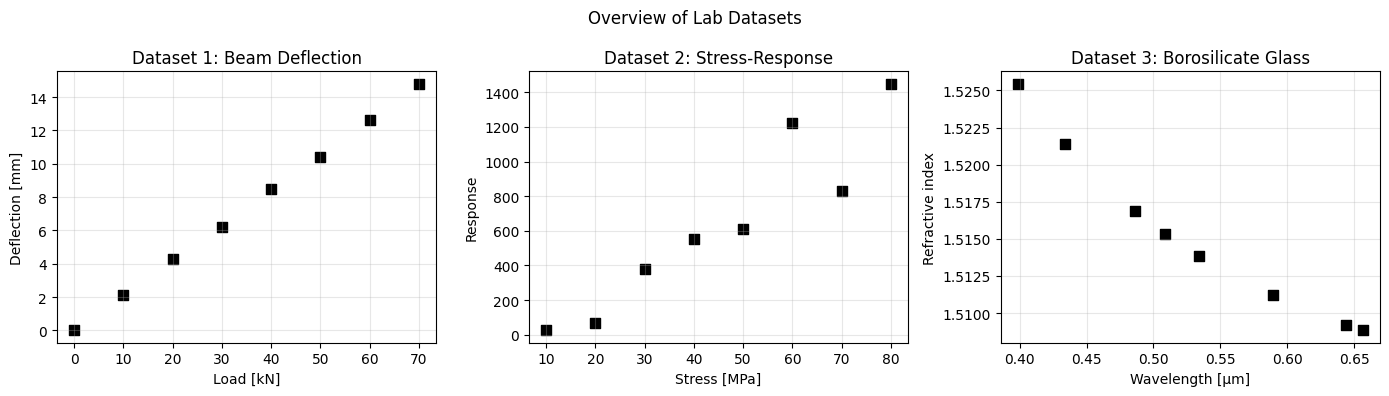

In [2]:
# Dataset 1: Beam deflection (clearly linear)
load       = np.array([0, 10, 20, 30, 40, 50, 60, 70], dtype=float)   # kN
deflection = np.array([0.0, 2.1, 4.3, 6.2, 8.5, 10.4, 12.6, 14.8])   # mm

# Dataset 2: Stress-response data (power law behavior)
stress   = np.linspace(1, 8, 8) * 10.0                                # MPa
response = np.array([25, 70, 380, 550, 610, 1220, 830, 1450], dtype=float)

# Dataset 3: Borosilicate glass refractive index (Cauchy equation)
wavelength = np.array([0.6563, 0.6439, 0.5890, 0.5338,
                       0.5086, 0.4861, 0.4340, 0.3988])  # micrometers
ridx       = np.array([1.50883, 1.50917, 1.51124, 1.51386,
                       1.51534, 1.51690, 1.52136, 1.52546])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(load, deflection, c='k', marker='s', s=60)
axes[0].set(xlabel='Load [kN]', ylabel='Deflection [mm]',
            title='Dataset 1: Beam Deflection')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(stress, response, c='k', marker='s', s=60)
axes[1].set(xlabel='Stress [MPa]', ylabel='Response',
            title='Dataset 2: Stress-Response')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(wavelength, ridx, c='k', marker='s', s=60)
axes[2].set(xlabel='Wavelength [\u03bcm]', ylabel='Refractive index',
            title='Dataset 3: Borosilicate Glass')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Overview of Lab Datasets', fontsize=12)
plt.tight_layout(); plt.show()

### 1.3 Sample Statistics Review

| Statistic | Formula | Interpretation |
|-----------|---------|----------------|
| Mean | $\bar{y} = \frac{1}{n}\sum y_i$ | Central tendency |
| Sample variance | $s_y^2 = \frac{\sum(y_i - \bar{y})^2}{n-1}$ | Spread (unbiased) |
| Std. deviation | $s_y = \sqrt{s_y^2}$ | Typical deviation |
| Coeff. of variation | $CV = 100\% \cdot s_y / \bar{y}$ | Relative variability |

=== Beam Deflection: Sample Statistics ===
n               = 8
mean            = 7.3625 mm
std dev (n-1)   = 5.1533 mm
CV              = 69.99 %
SST (corrected) = 185.898750


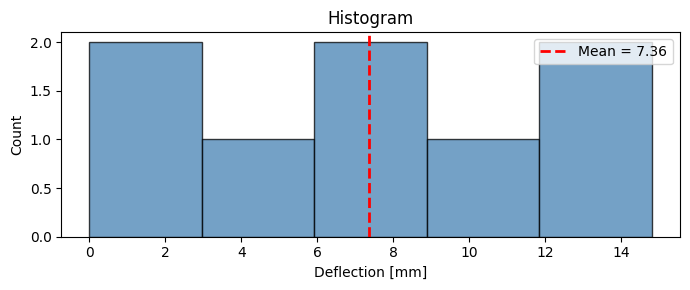

In [3]:
y = deflection
n = len(y)
y_mean = np.mean(y)
y_std  = np.std(y, ddof=1)    # ddof=1 -> unbiased (divide by n-1)
SST_raw = np.sum((y - y_mean)**2)

print('=== Beam Deflection: Sample Statistics ===')
print(f'n               = {n}')
print(f'mean            = {y_mean:.4f} mm')
print(f'std dev (n-1)   = {y_std:.4f} mm')
print(f'CV              = {y_std/y_mean*100:.2f} %')
print(f'SST (corrected) = {SST_raw:.6f}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(y, bins=5, edgecolor='k', color='steelblue', alpha=0.75)
ax.axvline(y_mean, color='r', ls='--', lw=2, label=f'Mean = {y_mean:.2f}')
ax.set(xlabel='Deflection [mm]', ylabel='Count', title='Histogram')
ax.legend(); plt.tight_layout(); plt.show()

---
## 2. Simple Linear Regression

### 2.1 Least Squares Formulas

Fit $\hat{y} = a_0 + a_1 x$ by minimizing $S_r = \sum(y_i - a_0 - a_1 x_i)^2$.
Setting partial derivatives to zero gives:

$$a_1 = \frac{n\sum x_i y_i - \sum x_i \sum y_i}{n\sum x_i^2 - \bigl(\sum x_i\bigr)^2}
      = \frac{\sum x_i y_i - n\bar{x}\bar{y}}{\sum x_i^2 - n\bar{x}^2},
\qquad a_0 = \bar{y} - a_1 \bar{x}$$

### 2.2 Goodness-of-Fit Statistics

| Quantity | Formula | Meaning |
|----------|---------|--------|
| $S_T$ | $\sum(y_i - \bar{y})^2$ | Total sum of squares |
| $S_r$ (SSE) | $\sum(y_i - \hat{y}_i)^2$ | Residual (unexplained) SS |
| SSR | $S_T - S_r$ | Explained SS |
| $R^2$ | $1 - S_r/S_T$ | Fraction of variance explained |
| $s_e$ | $\sqrt{S_r/(n-2)}$ | Standard error of the estimate |

<!-- a1 =                  # (n*np.sum(xi*yi) - np.sum(xi)*np.sum(yi)) / (n*np.sum(xi**2) - np.sum(xi)**2)
a0 =                  # np.mean(yi) - a1 * np.mean(xi) -->

In [ ]:
def linreg(xi, yi):
    """
    Simple linear regression: fit y = a0 + a1*x via least squares.

    Returns
    -------
    a0 : intercept
    a1 : slope
    """
    xi = np.array(xi, dtype=float)
    yi = np.array(yi, dtype=float)
    n  = len(xi)

    # --- COMPLETE ---
    a1 =                  
    a0 =                  
    # --- COMPLETE ---

    return a0, a1

<!-- SOLUTION
a1 = (n*np.sum(xi*yi) - np.sum(xi)*np.sum(yi)) / (n*np.sum(xi**2) - np.sum(xi)**2)
a0 = np.mean(yi) - a1 * np.mean(xi)
-->

Slope     a1 = 0.210357 mm/kN
Intercept a0 = 0.000000 mm
Stiffness  k = 1/a1 = 4.7538 kN/mm


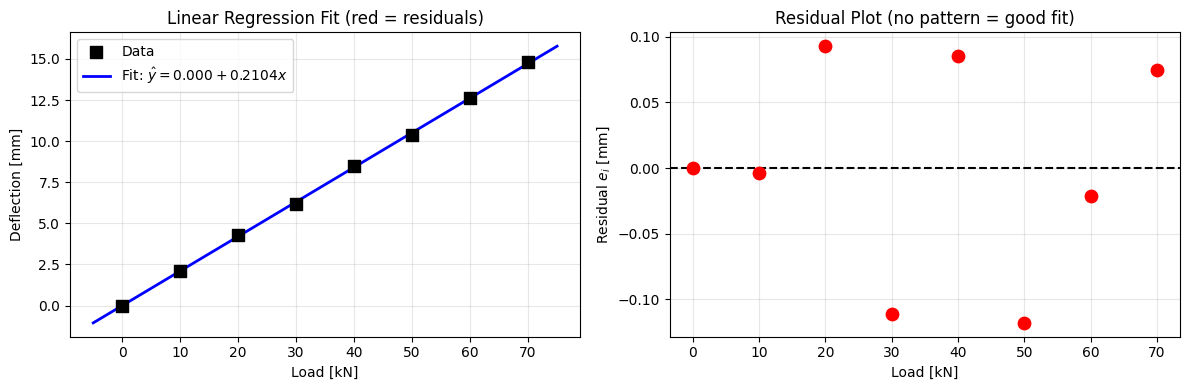

In [5]:
a0, a1 = linreg(load, deflection)
print(f'Slope     a1 = {a1:.6f} mm/kN')
print(f'Intercept a0 = {a0:.6f} mm')
print(f'Stiffness  k = 1/a1 = {1/a1:.4f} kN/mm')

x_fit = np.linspace(-5, 75, 200)
y_fit = a0 + a1 * x_fit
residuals_lin = deflection - (a0 + a1 * load)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.scatter(load, deflection, c='k', marker='s', s=80, zorder=5, label='Data')
ax.plot(x_fit, y_fit, 'b-', lw=2,
        label=f'Fit: $\\hat{{y}} = {a0:.3f} + {a1:.4f}x$')
for xi_i, yi_i in zip(load, deflection):
    ax.plot([xi_i, xi_i], [yi_i, a0 + a1*xi_i], 'r-', lw=1.2, alpha=0.7)
ax.set(xlabel='Load [kN]', ylabel='Deflection [mm]',
       title='Linear Regression Fit (red = residuals)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(load, residuals_lin, c='r', s=80, zorder=5)
ax.axhline(0, color='k', lw=1.5, ls='--')
ax.set(xlabel='Load [kN]', ylabel='Residual $e_i$ [mm]',
       title='Residual Plot (no pattern = good fit)')
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [ ]:
def goodness_of_fit(yi, yi_hat, n_params=2):
    """
    Compute goodness-of-fit statistics.

    Returns dict: SST, SSE, SSR, R2, R2adj, se
    """
    n     = len(yi)
    y_bar = np.mean(yi)

    # --- COMPLETE ---
    SST =             # np.sum((yi - y_bar)**2)   # total sum of squares
    SSE =             # np.sum((yi - yi_hat)**2)  # residual sum of squares
    SSR =             # SST - SSE                 # regression sum of squares
    R2  =             # 1 - SSE / SST             # coefficient of determination
    # --- COMPLETE ---

    se    = np.sqrt(SSE / (n - n_params))
    R2adj = 1 - (SSE / (n - n_params)) / (SST / (n - 1))
    return dict(SST=SST, SSE=SSE, SSR=SSR, R2=R2, R2adj=R2adj, se=se)

<!-- SOLUTION
SST = np.sum((yi - y_bar)**2)
SSE = np.sum((yi - yi_hat)**2)
SSR = SST - SSE
R2  = 1 - SSE / SST
-->

In [7]:
yhat_lin = a0 + a1 * load
gof_lin  = goodness_of_fit(deflection, yhat_lin, n_params=2)

print('=== Goodness of Fit: Beam Deflection (Linear) ===')
print(f'SST    = {gof_lin["SST"]:.6f}   (total variation)')
print(f'SSE    = {gof_lin["SSE"]:.6f}   (residual/unexplained)')
print(f'SSR    = {gof_lin["SSR"]:.6f}   (explained by model)')
print(f'R2     = {gof_lin["R2"]:.8f}')
print(f'Adj R2 = {gof_lin["R2adj"]:.8f}')
print(f'se     = {gof_lin["se"]:.6f} mm')
print(f'SST = SSR + SSE? {np.isclose(gof_lin["SST"], gof_lin["SSR"] + gof_lin["SSE"])}')

=== Goodness of Fit: Beam Deflection (Linear) ===
SST    = 185.898750   (total variation)
SSE    = 0.048214   (residual/unexplained)
SSR    = 185.850536   (explained by model)
R2     = 0.99974064
Adj R2 = 0.99969742
se     = 0.089642 mm
SST = SSR + SSE? True


In [8]:
# Compare with scipy and numpy built-ins
res_sc = stats.linregress(load, deflection)
poly1  = np.polyfit(load, deflection, 1)   # returns [a1, a0]

print('=== Method Comparison ===')
print(f'{"Method":<24}  {"a1 (slope)":>14}  {"a0 (intercept)":>16}  {"R2":>10}')
print('-' * 72)
print(f'{"Our linreg":<24}  {a1:>14.8f}  {a0:>16.8f}  {gof_lin["R2"]:>10.8f}')
print(f'{"scipy.stats.linregress":<24}  {res_sc.slope:>14.8f}  '
      f'{res_sc.intercept:>16.8f}  {res_sc.rvalue**2:>10.8f}')
print(f'{"np.polyfit(deg=1)":<24}  {poly1[0]:>14.8f}  {poly1[1]:>16.8f}')

=== Method Comparison ===
Method                        a1 (slope)    a0 (intercept)          R2
------------------------------------------------------------------------
Our linreg                    0.21035714        0.00000000  0.99974064
scipy.stats.linregress        0.21035714        0.00000000  0.99974064
np.polyfit(deg=1)             0.21035714       -0.00000000


---
## 3. Linearizable Nonlinear Regression

### 3.1 Power Law:  $y = \alpha x^\beta$

Take $\log_{10}$ of both sides:
$$\underbrace{\log_{10} y}_{Y} = \underbrace{\log_{10} \alpha}_{A_0} +
  \beta \underbrace{\log_{10} x}_{X}
\quad\Rightarrow\quad Y = A_0 + \beta X \;\text{(linear!)}$$

Recovery: $\beta = A_1$, $\alpha = 10^{A_0}$.

### 3.2 Exponential: $y = \alpha e^{\beta x}$

$$\ln y = \ln\alpha + \beta x
\quad\Rightarrow\quad \ln y = B_0 + B_1 x \;\text{(linear!)}$$

Recovery: $\beta = B_1$, $\alpha = e^{B_0}$.

> **Caution:** log-linearization minimizes SSE in **transformed** (log) space, not the original $y$ space.
> For large noise, use `curve_fit` (Section 5) for exact nonlinear least squares.

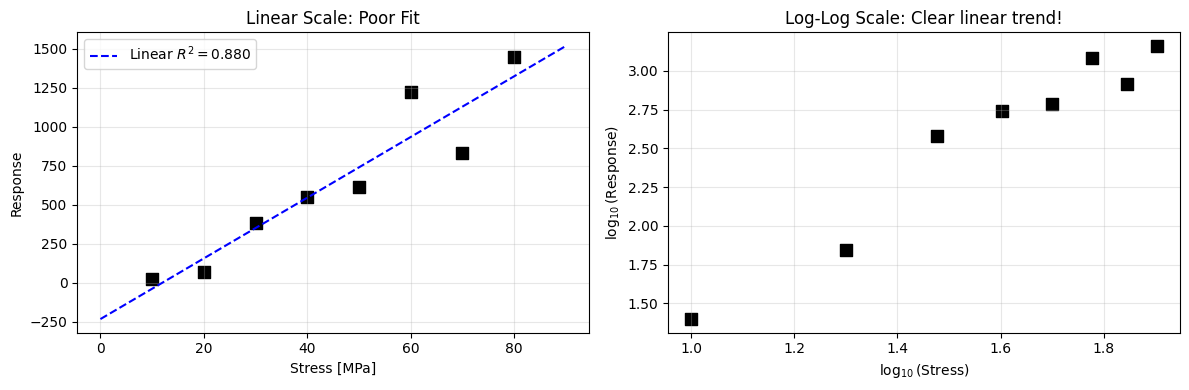

In [9]:
# Motivate log-log plot for stress-response data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

a0_bad, a1_bad = linreg(stress, response)
yhat_bad = a0_bad + a1_bad * stress
gof_bad  = goodness_of_fit(response, yhat_bad)

ax = axes[0]
ax.scatter(stress, response, c='k', marker='s', s=80)
xp = np.linspace(0, 90, 200)
ax.plot(xp, a0_bad + a1_bad * xp, 'b--', lw=1.5,
        label=f'Linear $R^2={gof_bad["R2"]:.3f}$')
ax.set(xlabel='Stress [MPa]', ylabel='Response',
       title='Linear Scale: Poor Fit')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(np.log10(stress), np.log10(response), c='k', marker='s', s=80)
ax.set(xlabel='$\\log_{10}$(Stress)', ylabel='$\\log_{10}$(Response)',
       title='Log-Log Scale: Clear linear trend!')
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [ ]:
def power_fit(xi, yi):
    """
    Fit y = alpha * x^beta using log10 linearization.

    Returns
    -------
    alpha, beta : power law parameters
    A0, A1      : intercept and slope in log10 space
    """
    xi = np.array(xi, dtype=float)
    yi = np.array(yi, dtype=float)

    # --- COMPLETE: transform to log10 space ---
    X =              # np.log10(xi)
    Y =              # np.log10(yi)
    # --- COMPLETE ---

    A0, A1 = linreg(X, Y)      # fit in log space

    # --- COMPLETE: recover power law parameters ---
    alpha =          # 10**A0
    beta  =          # A1
    # --- COMPLETE ---

    return alpha, beta, A0, A1

<!-- SOLUTION
X     = np.log10(xi)
Y     = np.log10(yi)
alpha = 10**A0
beta  = A1
-->

Power law fit:  y = 0.2741 * x^1.9842
Exponent beta ~ 1.98  (response ~ stress squared)


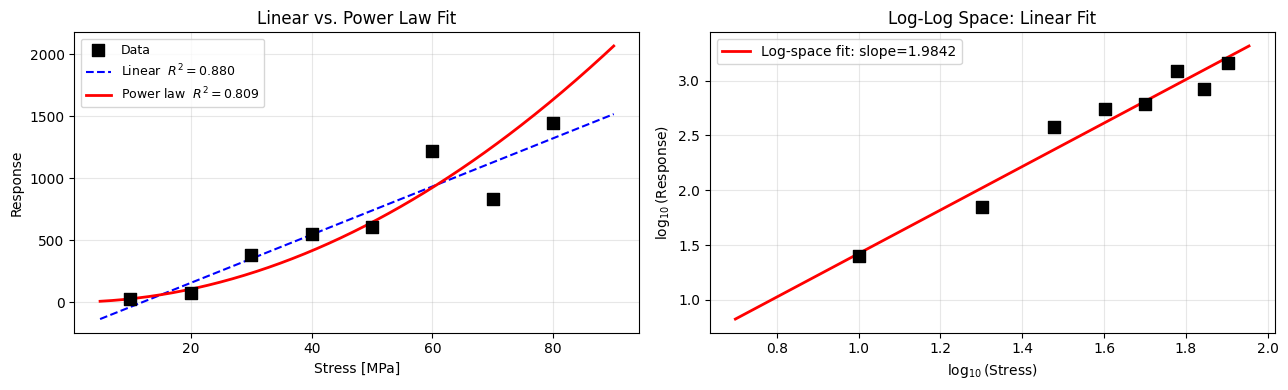

Linear:    R2=0.88049,  se=189.79
Power law: R2=0.80882,  se=240.04


In [11]:
alpha_pw, beta_pw, A0, A1 = power_fit(stress, response)
print(f'Power law fit:  y = {alpha_pw:.4f} * x^{beta_pw:.4f}')
print(f'Exponent beta ~ {beta_pw:.2f}  (response ~ stress squared)')

yhat_pw = alpha_pw * stress**beta_pw
gof_pw  = goodness_of_fit(response, yhat_pw, n_params=2)

x_plt = np.linspace(5, 90, 300)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(stress, response, c='k', marker='s', s=80, zorder=5, label='Data')
ax.plot(x_plt, a0_bad + a1_bad*x_plt, 'b--', lw=1.5,
        label=f'Linear  $R^2={gof_bad["R2"]:.3f}$')
ax.plot(x_plt, alpha_pw*x_plt**beta_pw, 'r-', lw=2,
        label=f'Power law  $R^2={gof_pw["R2"]:.3f}$')
ax.set(xlabel='Stress [MPa]', ylabel='Response',
       title='Linear vs. Power Law Fit')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
X_plt = np.log10(x_plt)
ax.scatter(np.log10(stress), np.log10(response), c='k', marker='s', s=80, zorder=5)
ax.plot(X_plt, A0 + A1*X_plt, 'r-', lw=2,
        label=f'Log-space fit: slope={A1:.4f}')
ax.set(xlabel='$\\log_{{10}}$(Stress)', ylabel='$\\log_{{10}}$(Response)',
       title='Log-Log Space: Linear Fit')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Linear:    R2={gof_bad["R2"]:.5f},  se={gof_bad["se"]:.2f}')
print(f'Power law: R2={gof_pw["R2"]:.5f},  se={gof_pw["se"]:.2f}')

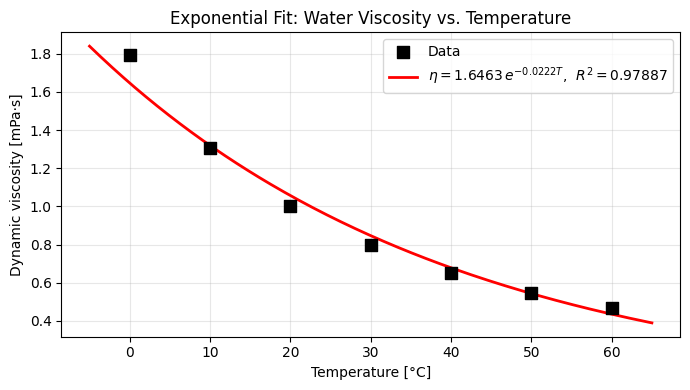

In [12]:
# Exponential fit: y = alpha * exp(beta * x)
# Example: water viscosity vs. temperature (Arrhenius-type decay)
T_visc  = np.array([0, 10, 20, 30, 40, 50, 60], dtype=float)  # degC
eta     = np.array([1.792, 1.307, 1.002, 0.798, 0.653, 0.547, 0.467])  # mPa s

# ln(eta) = ln(alpha) + beta*T
lnY = np.log(eta)
B0, B1 = linreg(T_visc, lnY)
alpha_exp = np.exp(B0)
beta_exp  = B1

yhat_exp = alpha_exp * np.exp(beta_exp * T_visc)
gof_exp  = goodness_of_fit(eta, yhat_exp, n_params=2)

T_fit = np.linspace(-5, 65, 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(T_visc, eta, c='k', marker='s', s=80, zorder=5, label='Data')
ax.plot(T_fit, alpha_exp * np.exp(beta_exp * T_fit), 'r-', lw=2,
        label=f'$\\eta = {alpha_exp:.4f}\\,e^{{{beta_exp:.4f}T}}$,  $R^2={gof_exp["R2"]:.5f}$')
ax.set(xlabel='Temperature [\u00b0C]', ylabel='Dynamic viscosity [mPa\u00b7s]',
       title='Exponential Fit: Water Viscosity vs. Temperature')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 4. General Linear Least Squares

### 4.1 The Normal Equations

Any model **linear in parameters** $\mathbf{c}$ can be written as $\hat{y} = \mathbf{X}\mathbf{c}$,
where the **design matrix** $\mathbf{X}$ ($n\times(m+1)$) has rows $[z_0(x_i), z_1(x_i), \ldots, z_m(x_i)]$.

The least squares solution satisfies:
$$\mathbf{X}^T\mathbf{X}\,\mathbf{c} = \mathbf{X}^T\mathbf{y}
\quad\Rightarrow\quad
\mathbf{c} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

| Basis functions $z_j(x)$ | Model |
|--------------------------|-------|
| $1,\;x$ | Simple linear |
| $1,\;x,\;x^2,\;\ldots,\;x^m$ | Polynomial of degree $m$ |
| $1,\;1/\lambda^2,\;1/\lambda^4$ | Cauchy's equation |
| $1,\;x_1,\;x_2$ | Multiple linear regression |

When $n > m+1$ the system is **overdetermined** — use the normal equations
or `np.linalg.lstsq` (more numerically stable).

In [ ]:
def poly_lstsq(xi, yi, m):
    """
    Polynomial regression: fit y = c0 + c1*x + ... + cm*x^m.

    Parameters
    ----------
    xi, yi : array-like
    m      : int  — polynomial degree

    Returns
    -------
    c : array  — coefficients [c0, c1, ..., cm]
    X : array  — design matrix  (n x (m+1))
    """
    xi = np.array(xi, dtype=float)
    yi = np.array(yi, dtype=float)
    n  = len(xi)

    # --- COMPLETE: build design matrix ---
    X = np.zeros((n, m + 1))
    for j in range(m + 1):
        X[:, j] =            # xi**j  # (j-th column = x to the power j)
    # --- COMPLETE ---

    # --- COMPLETE: solve normal equations X^T X c = X^T y ---
    c =                      # np.linalg.solve(X.T @ X, X.T @ yi)
    # --- COMPLETE ---

    return c, X

<!-- SOLUTION
X[:, j] = xi**j
c       = np.linalg.solve(X.T @ X, X.T @ yi)
-->

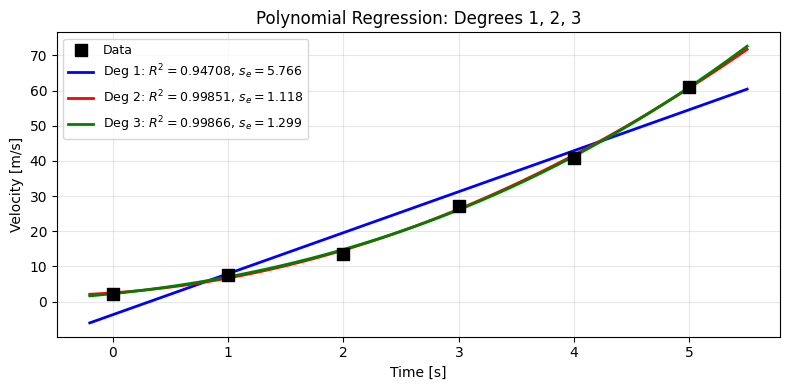

Quadratic: y = 2.4786 + 2.3593t + 1.8607t²


In [14]:
# Polynomial regression on velocity data (quadratic model expected)
x_vel = np.array([0., 1., 2., 3., 4., 5.], dtype=float)  # time [s]
y_vel = np.array([2.1, 7.7, 13.6, 27.2, 40.9, 61.1])     # velocity [m/s]

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x_vel, y_vel, c='k', marker='s', s=80, zorder=5, label='Data')

colors = ['blue', 'red', 'green']
for m, col in zip([1, 2, 3], colors):
    c, X = poly_lstsq(x_vel, y_vel, m)
    x_plt = np.linspace(-0.2, 5.5, 300)
    y_plt = sum(c[j] * x_plt**j for j in range(m + 1))
    yhat  = X @ c
    gof_p = goodness_of_fit(y_vel, yhat, n_params=m + 1)
    ax.plot(x_plt, y_plt, color=col, lw=2,
            label=f'Deg {m}: $R^2={gof_p["R2"]:.5f}$, $s_e={gof_p["se"]:.3f}$')

ax.set(xlabel='Time [s]', ylabel='Velocity [m/s]',
       title='Polynomial Regression: Degrees 1, 2, 3')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

c2, _ = poly_lstsq(x_vel, y_vel, 2)
print(f'Quadratic: y = {c2[0]:.4f} + {c2[1]:.4f}t + {c2[2]:.4f}t\u00b2')

Design matrix shape: (8, 3)  <- overdetermined (8 eqs, 3 unknowns)
c0 = 1.49887227   (background index)
c1 = 4.321169e-03
c2 = -1.508560e-05
lstsq agrees: True


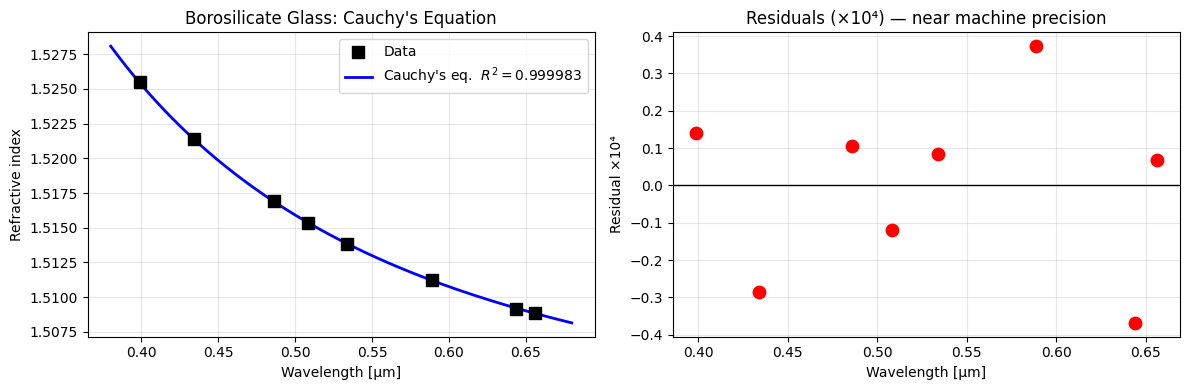

R2=0.99998281,  se=2.875e-05


In [15]:
# Cauchy's equation for borosilicate glass: n(lam) = c0 + c1/lam^2 + c2/lam^4
# 8 data points, 3 parameters -> OVERDETERMINED
lam = wavelength
X_c = np.column_stack([np.ones(len(lam)), 1.0/lam**2, 1.0/lam**4])
print(f'Design matrix shape: {X_c.shape}  <- overdetermined (8 eqs, 3 unknowns)')

# Cannot use np.linalg.solve on a rectangular matrix -> use normal equations
c_cauchy = np.linalg.solve(X_c.T @ X_c, X_c.T @ ridx)
# Equivalent (more robust): np.linalg.lstsq
c_lstsq, _, _, _ = np.linalg.lstsq(X_c, ridx, rcond=None)

print(f'c0 = {c_cauchy[0]:.8f}   (background index)')
print(f'c1 = {c_cauchy[1]:.6e}')
print(f'c2 = {c_cauchy[2]:.6e}')
print(f'lstsq agrees: {np.allclose(c_cauchy, c_lstsq)}')

yhat_c = X_c @ c_cauchy
gof_c  = goodness_of_fit(ridx, yhat_c, n_params=3)

lam_fit = np.linspace(0.38, 0.68, 300)
n_fit   = c_cauchy[0] + c_cauchy[1]/lam_fit**2 + c_cauchy[2]/lam_fit**4

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.scatter(lam, ridx, c='k', marker='s', s=80, zorder=5, label='Data')
ax.plot(lam_fit, n_fit, 'b-', lw=2,
        label=f"Cauchy's eq.  $R^2={gof_c['R2']:.6f}$")
ax.set(xlabel='Wavelength [\u03bcm]', ylabel='Refractive index',
       title="Borosilicate Glass: Cauchy's Equation")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(lam, (ridx - yhat_c) * 1e4, c='r', s=80, zorder=5)
ax.axhline(0, color='k', lw=1)
ax.set(xlabel='Wavelength [\u03bcm]', ylabel='Residual \u00d710\u2074',
       title='Residuals (\u00d710\u2074) — near machine precision')
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f'R2={gof_c["R2"]:.8f},  se={gof_c["se"]:.3e}')

In [16]:
# Multiple linear regression: y = c0 + c1*x1 + c2*x2
x1_d = np.array([0,   2,   2.5, 1,  4,  7  ], dtype=float)
x2_d = np.array([0,   1,   2,   3,  6,  2  ], dtype=float)
y_d  = np.array([5.16, 9.91, 8.91, 0.27, 3.07, 27.04])

X_mlr = np.column_stack([np.ones(len(x1_d)), x1_d, x2_d])
c_mlr = np.linalg.solve(X_mlr.T @ X_mlr, X_mlr.T @ y_d)

print('=== Multiple Linear Regression: y = c0 + c1*x1 + c2*x2 ===')
print(f'c0 = {c_mlr[0]:.6f}')
print(f'c1 = {c_mlr[1]:.6f}')
print(f'c2 = {c_mlr[2]:.6f}')
gof_mlr = goodness_of_fit(y_d, X_mlr @ c_mlr, n_params=3)
print(f'R2 = {gof_mlr["R2"]:.6f},  se = {gof_mlr["se"]:.4f}')

=== Multiple Linear Regression: y = c0 + c1*x1 + c2*x2 ===
c0 = 5.080125
c1 = 3.975452
c2 = -2.979694
R2 = 0.999819,  se = 0.1650


---
## 5. Nonlinear Regression via `scipy.optimize.curve_fit`

### 5.1 When Linearization Fails

Some models cannot be linearized:
- Michaelis-Menten: $y = V_{\max} x / (K_m + x)$
- Antoine equation: $\log_{10} P = A - B/(C + T)$

`curve_fit` minimizes $\sum(y_i - f(x_i;\mathbf{c}))^2$ directly using the
Levenberg-Marquardt algorithm (a damped Newton method).

```python
popt, pcov = curve_fit(f, xdata, ydata, p0=initial_guess)
# popt : optimal parameters
# pcov : covariance matrix  ->  perr = np.sqrt(np.diag(pcov))  gives std errors
```

In [17]:
# Power law via curve_fit vs. log-linearization — comparison
def power_model(x, alpha, beta):
    return alpha * x**beta

popt_pw, pcov_pw = curve_fit(power_model, stress, response, p0=[1.0, 2.0])
alpha_cf, beta_cf = popt_pw
perr_pw = np.sqrt(np.diag(pcov_pw))

yhat_cf = power_model(stress, *popt_pw)
gof_cf  = goodness_of_fit(response, yhat_cf, n_params=2)

print('=== Power Law: Log-linearization vs. curve_fit ===')
print(f'{"":22s}  {"alpha":>12}  {"beta":>12}  {"R2":>10}')
print('-' * 62)
print(f'{"Log-linearization":<22}  {alpha_pw:>12.6f}  {beta_pw:>12.6f}  {gof_pw["R2"]:>10.6f}')
print(f'{"curve_fit":<22}  {alpha_cf:>12.6f}  {beta_cf:>12.6f}  {gof_cf["R2"]:>10.6f}')
print(f'{"curve_fit std err":<22}  {perr_pw[0]:>12.6f}  {perr_pw[1]:>12.6f}')
print('\nNote: curve_fit minimizes SSE in the original y-space;')
print('      log-linearization minimizes SSE in log(y) space.')

=== Power Law: Log-linearization vs. curve_fit ===
                               alpha          beta          R2
--------------------------------------------------------------
Log-linearization           0.274137      1.984176    0.808818
curve_fit                   2.538367      1.435856    0.876898
curve_fit std err           3.620273      0.340430

Note: curve_fit minimizes SSE in the original y-space;
      log-linearization minimizes SSE in log(y) space.


=== Antoine Equation Fit (water vapor pressure) ===
A = 7.997574 +/- 0.007401
B = 1687.0509 +/- 4.6041
C = 229.7113 +/- 0.4237
R2 = 0.99999999
Literature: A=8.07131, B=1730.63, C=233.426


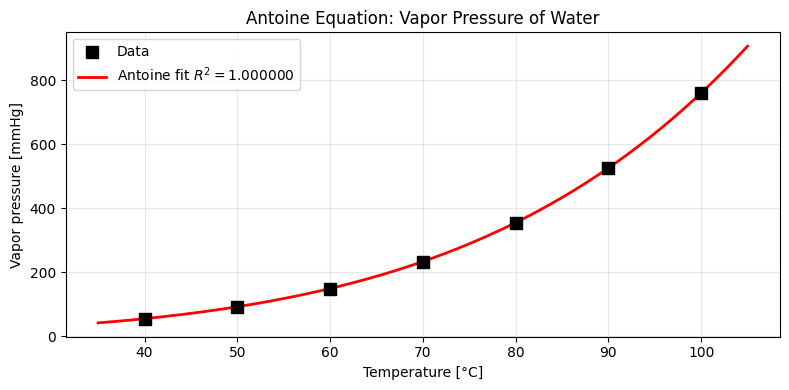

In [ ]:
# Antoine equation: log10(P) = A - B/(C+T)  -> P = 10^(A - B/(C+T))
T_ant = np.array([40, 50, 60, 70, 80, 90, 100], dtype=float)    # degC
P_ant = np.array([55.3, 92.5, 149.4, 233.7, 355.1, 525.8, 760.0])  # mmHg

def antoine_model(T, A, B, C):
    return 10.0**(A - B / (C + T))

# --- COMPLETE: fit the Antoine equation ---
p0_ant = [8.0, 1500.0, 200.0]
popt_ant, pcov_ant =     # curve_fit(antoine_model, T_ant, P_ant, p0=p0_ant)
# --- COMPLETE ---

A_opt, B_opt, C_opt = popt_ant
perr_ant = np.sqrt(np.diag(pcov_ant))
gof_ant  = goodness_of_fit(P_ant, antoine_model(T_ant, *popt_ant), n_params=3)

print('=== Antoine Equation Fit (water vapor pressure) ===')
print(f'A = {A_opt:.6f} +/- {perr_ant[0]:.6f}')
print(f'B = {B_opt:.4f} +/- {perr_ant[1]:.4f}')
print(f'C = {C_opt:.4f} +/- {perr_ant[2]:.4f}')
print(f'R2 = {gof_ant["R2"]:.8f}')
print(f'Literature: A=8.07131, B=1730.63, C=233.426')

T_fit = np.linspace(35, 105, 300)
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(T_ant, P_ant, c='k', marker='s', s=80, zorder=5, label='Data')
ax.plot(T_fit, antoine_model(T_fit, *popt_ant), 'r-', lw=2,
        label=f'Antoine fit $R^2={gof_ant["R2"]:.6f}$')
ax.set(xlabel='Temperature [\u00b0C]', ylabel='Vapor pressure [mmHg]',
       title='Antoine Equation: Vapor Pressure of Water')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

<!-- SOLUTION
popt_ant, pcov_ant = curve_fit(antoine_model, T_ant, P_ant, p0=p0_ant)
-->

---
## 6. Model Comparison and Selection

Higher degree always increases $R^2$ — but can **overfit**.

| Criterion | Formula | Penalizes complexity? |
|-----------|---------|----------------------|
| $R^2$ | $1 - S_r/S_T$ | No |
| **Adj. $R^2$** | $1 - \frac{S_r/(n-m-1)}{S_T/(n-1)}$ | Yes — decreases if extra parameter adds noise |
| **$s_e$** | $\sqrt{S_r/(n-m-1)}$ | Yes — should decrease then flatten |
| **Residual plot** | $e_i$ vs $x_i$ | — Should show no systematic pattern |

 Degree          R2        Adj R2          se
---------------------------------------------
      1   0.8514521     0.8379478    0.190883
      2   0.9837378     0.9804854    0.066240
      3   0.9985234     0.9980312    0.021040
      4   0.9998335     0.9997503    0.007493
      5   0.9999585     0.9999289    0.003999
      6   0.9999905     0.9999810    0.002065
      7   0.9999993     0.9999984    0.000601
      8   0.9999997     0.9999990    0.000474


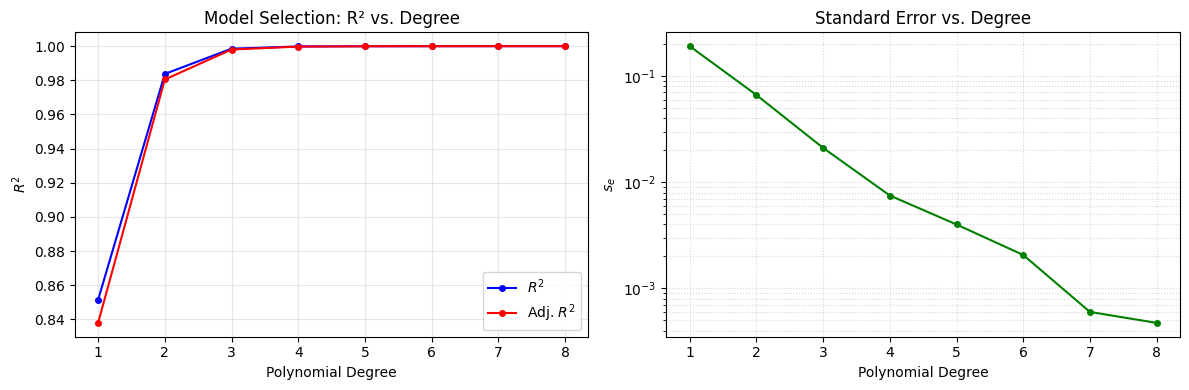


Observation: Adj. R² peaks around degree 4-5, then decreases -> overfitting!


In [20]:
# Viscosity vs. temperature: compare polynomial degrees 1..8
x_v = np.array([0, 4.44, 10, 15.56, 21.11, 26.67, 32.22,
                37.78, 48.89, 60, 71.11, 82.22, 93.33])
y_v = np.array([1.794, 1.546, 1.31, 1.129, 0.982, 0.862, 0.764,
                0.682, 0.559, 0.47, 0.401, 0.347, 0.305])

# Standardize x for numerical stability: z = (x - mean) / std
x_std = (x_v - np.mean(x_v)) / np.std(x_v)

degrees = list(range(1, 9))
metrics = []
for m in degrees:
    c, X = poly_lstsq(x_std, y_v, m)
    gof_m = goodness_of_fit(y_v, X @ c, n_params=m + 1)
    metrics.append((m, gof_m['R2'], gof_m['R2adj'], gof_m['se']))

print(f'{"Degree":>7}  {"R2":>10}  {"Adj R2":>12}  {"se":>10}')
print('-' * 45)
for row in metrics:
    print(f'{row[0]:>7}  {row[1]:>10.7f}  {row[2]:>12.7f}  {row[3]:>10.6f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(degrees, [r[1] for r in metrics], 'b.-', ms=8, label='$R^2$')
ax.plot(degrees, [r[2] for r in metrics], 'r.-', ms=8, label='Adj. $R^2$')
ax.set(xlabel='Polynomial Degree', ylabel='$R^2$',
       title='Model Selection: R\u00b2 vs. Degree')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(degrees, [r[3] for r in metrics], 'g.-', ms=8)
ax.set(xlabel='Polynomial Degree', ylabel='$s_e$',
       title='Standard Error vs. Degree')
ax.grid(True, which='both', ls=':', alpha=0.5)

plt.tight_layout(); plt.show()
print('\nObservation: Adj. R\u00b2 peaks around degree 4-5, then decreases -> overfitting!')

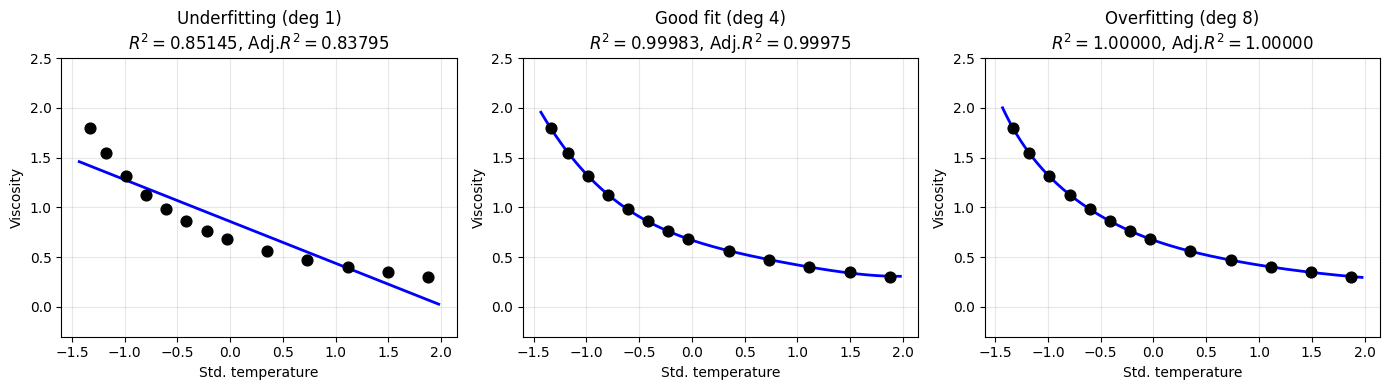

In [21]:
# Visual: underfitting, good fit, overfitting
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ['Underfitting (deg 1)', 'Good fit (deg 4)', 'Overfitting (deg 8)']

for ax, m, title in zip(axes, [1, 4, 8], titles):
    c, X = poly_lstsq(x_std, y_v, m)
    gof_m = goodness_of_fit(y_v, X @ c, n_params=m + 1)
    x_fit2 = np.linspace(x_std.min() - 0.1, x_std.max() + 0.1, 300)
    y_plt  = sum(c[j] * x_fit2**j for j in range(m + 1))
    ax.scatter(x_std, y_v, c='k', s=60, zorder=5)
    ax.plot(x_fit2, y_plt, 'b-', lw=2)
    ax.set(xlabel='Std. temperature', ylabel='Viscosity',
           title=f'{title}\n$R^2={gof_m["R2"]:.5f}$, Adj.$R^2={gof_m["R2adj"]:.5f}$',
           ylim=[-0.3, 2.5])
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## Summary

### Methods Overview

| Method | Model | Key Formula | When to Use |
|--------|-------|-------------|-------------|
| **Simple linear** | $a_0 + a_1 x$ | $a_1 = \frac{n\sum x_i y_i - \sum x_i \sum y_i}{n\sum x_i^2 - (\sum x_i)^2}$ | Linear scatter |
| **Power law** | $\alpha x^\beta$ | Log-log transform, then linear | Log-log plot is linear |
| **Exponential** | $\alpha e^{\beta x}$ | $\ln y$ vs $x$, then linear | Semi-log plot is linear |
| **Polynomial** | $\sum c_j x^j$ | Normal equations | Smooth curves |
| **General linear** | $\sum c_j z_j(x)$ | $(\mathbf{X}^T\mathbf{X})\mathbf{c}=\mathbf{X}^T\mathbf{y}$ | Known basis functions |
| **Nonlinear** | $f(x; \mathbf{c})$ | `scipy.curve_fit` | Cannot linearize |

### Key Formulas

| Statistic | Formula | Interpretation |
|-----------|---------|----------------|
| $S_T$ | $\sum(y_i - \bar{y})^2$ | Total variance |
| $S_r$ (SSE) | $\sum(y_i - \hat{y}_i)^2$ | Unexplained variance |
| $R^2$ | $1 - S_r/S_T$ | Fraction explained (0 bad, 1 perfect) |
| Adj. $R^2$ | $1 - \frac{S_r/(n-m-1)}{S_T/(n-1)}$ | Penalizes extra parameters |
| $s_e$ | $\sqrt{S_r/(n-m-1)}$ | Typical prediction error |
| Normal eqs | $(\mathbf{X}^T\mathbf{X})\mathbf{c} = \mathbf{X}^T\mathbf{y}$ | Overdetermined LSQ |

### Decision Guide

```
Is y vs. x linear?
  YES -> Simple linear regression (linreg)
  NO  -> Is log-log(y vs. x) linear?
           YES -> Power law (power_fit)
         Is ln(y) vs. x linear?
           YES -> Exponential (log-linearize)
         Do you know the functional form?
           YES, linear in params -> Normal equations (poly_lstsq or np.linalg.lstsq)
           YES, nonlinear        -> scipy.curve_fit
           NO                   -> Polynomial (check Adj. R^2 to choose degree)
```

### Engineering Applications

| Application | Model | Method |
|-------------|-------|--------|
| Beam deflection $\delta$ vs. load $P$ | Linear | `linreg` |
| Fatigue life vs. stress amplitude | Power law | `power_fit` |
| Viscosity vs. temperature | Exponential | log-linearize |
| Glass refractive index vs. wavelength | Cauchy's equation | Normal equations |
| Vapor pressure vs. temperature | Antoine equation | `curve_fit` |